In [2]:
# Necessary packages to run this file:
import spectral
import spectral.io.envi as envi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.image as img
from scipy.ndimage import gaussian_filter
from skimage.restoration import richardson_lucy
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Helper functions:

In [3]:
def get_file_paths(base_path):
    folders = sorted([
        f for f in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, f))])
    file_numbers = []
    for f in folders:
        for l in os.listdir(base_path+f+'/metadata/'):
            if l.endswith('.xml'):
                file_numbers.append(str(l.replace('.xml', '')))
    if int(len(folders)) != int(len(file_numbers)):
        print("Warning: couldn't find all file numbers; returning empty arrays.")
        return [], []
    return folders, file_numbers


# TODO: generalisoi
# Returns two arrays: first one with the folder path "kitchen[day2]/[object]" and the second with the corresponding file number.
def get_all_file_paths(path):
    folders1, nums1 = get_file_paths(path+'kitchen/')
    folders1 = folders1[0:-2]                                   # Jätetään pois sekoitteet
    for f in range(len(folders1)):
        folders1[f] = 'kitchen/'+folders1[f]+'/'
    folders2, nums2 = get_file_paths(path+'kitchenday2/')
    for f in range(len(folders2)):
        folders2[f] = 'kitchenday2/'+folders2[f]+'/'
    return folders1, nums1                                      # Käsitellään toistaiseksi vain kitchen-dataa, ei kitchenday2


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def open_image(file_path):
    try:
        image = envi.open(file_path)
        data = image.load()

        wavelengths = image.metadata.get('wavelength', None)
        if wavelengths:
            wavelengths = [float(w) for w in wavelengths]

        return data, wavelengths

    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        return None, None


# Data on nyt kuutio.
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def load_and_compute_reflectance(path, folder_name, file_number):
    folder_path = path + folder_name + '/capture/'
    paths = {
        'raw':   os.path.join(folder_path, f"{file_number}.hdr"),
        'white': os.path.join(folder_path, f"WHITEREF_{file_number}.hdr"),
        'dark':  os.path.join(folder_path, f"DARKREF_{file_number}.hdr"),
    }

    for key, p in paths.items():
        if not os.path.isfile(p):
            print(f"  Missing {key} file: {p}")
            return None, None

    raw, wavelengths = open_image(paths['raw'])
    white, _ = open_image(paths['white'])
    dark, _  = open_image(paths['dark'])

    if any(x is None for x in [raw, white, dark]):
        print("  Failed to load one or more image cubes.")
        return None, None
    
    denominator = white - dark
    denominator[denominator == 0] = 1e-6

    # np.clip: limits the values between given given values, here 0 and 1
    reflectance = np.clip((raw - dark) / denominator, 0, 1)
    return reflectance, wavelengths


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def create_sample_mask(cube, band=None):
    if band is None:
        #band = 130
        #band = int(cube.shape[2]/2)
        band = min_max_reflectance(cube)[1]

    img = cube[:, :, band]
    img_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # Original:
    #_, mask = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    blur = cv2.GaussianBlur(img_u8,(5,5),0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #plt.imshow(mask)
    #plt.show()
    return mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def segment_sample(cube, mask, margin=5, roi_mode="single", min_roi_area=50):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("  Warning: no contours found; returning original image.")
        return cube.copy(), mask.copy()

    # Sort by area (largest first)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    roi_mask = np.zeros_like(mask, dtype=np.uint8)

    if roi_mode == "single":
        # Keep the largest contour whose polygon approximation has >= 5 vertices
        for c in contours:
            if len(cv2.approxPolyDP(c, 3, True)) >= 5:
                cv2.fillPoly(roi_mask, [c], 255)
                break
        else:
            # Fallback: use the largest contour regardless
            cv2.fillPoly(roi_mask, [contours[0]], 255)

    elif roi_mode == "multiple":
        for c in contours:
            if cv2.contourArea(c) >= min_roi_area:
                cv2.fillPoly(roi_mask, [c], 255)
    else:
        raise ValueError(f"roi_mode must be 'single' or 'multiple', got '{roi_mode}'")

    # Apply mask (element-wise multiply is correct for float arrays)
    filtered = cube * (roi_mask[:, :, np.newaxis] / 255.0)

    # Crop to bounding box of the combined mask
    # Rajaa kuvan vain maskiin.
    coords = cv2.findNonZero(roi_mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        x = max(0, x - margin)
        y = max(0, y - margin)
        w = min(cube.shape[1] - x, w + 2 * margin)
        h = min(cube.shape[0] - y, h + 2 * margin)
        segmented = filtered[y:y+h, x:x+w]
        roi_mask  = roi_mask[y:y+h, x:x+w]
    else:
        segmented = filtered

    return segmented, roi_mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def extract_mean_spectrum(cube, mask):
    pixels = cube[mask > 0]
    if pixels.size == 0:
        print("  Warning: mask is empty; returning zeros.")
        return np.zeros(cube.shape[2])
    return np.mean(pixels, axis=0)


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def min_max_reflectance(cube):
    min = int(np.argmin(np.mean(cube, axis=(0, 1))))
    max = int(np.argmax(np.mean(cube, axis=(0, 1))))
    return min, max


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def gaussian_psf(size=5, sigma=1.0):
    psf = np.zeros((size, size))
    psf[size // 2, size // 2] = 1.0
    psf = gaussian_filter(psf, sigma=sigma)
    return psf / psf.sum()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def apply_richardson_lucy(image, psf, num_iter=15):
    result = np.zeros_like(image)
    for b in range(image.shape[2]):
        result[:, :, b] = richardson_lucy(image[:, :, b], psf, num_iter=num_iter)
    return result


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def process_sample(path, folder_name, file_number, roi_mode="single", min_roi_area=50, margin=5, deblur=False, deblur_sigma=0.1, deblur_iter=5, visualize=False):
    cube, waves = load_and_compute_reflectance(path, folder_name, file_number)

    if deblur:
        psf = gaussian_psf(sigma=deblur_sigma)
        processed = apply_richardson_lucy(cube, psf, num_iter=deblur_iter)
        if visualize:
            visualize_step(cube, processed, title=f"Deblurring — {folder_name}")
    else:
        processed = cube

    mask = create_sample_mask(processed)
    if visualize:
        plt.imshow(mask, cmap='gray')
        plt.title('Binary mask')
        plt.axis('off')
        plt.show()

    segmented, roi_mask = segment_sample(
        processed, mask, margin=margin,
        roi_mode=roi_mode, min_roi_area=min_roi_area,
    )
    
    plt.imshow(roi_mask)
    plt.show()

    spectrum = extract_mean_spectrum(segmented, roi_mask)

    #visualize_step(cube, segmented)

    return spectrum, waves


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def visualize_step(original, processed, band=None, title=""):
    if band is None:
        band = min_max_reflectance(original)[1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(original[:, :, band], cmap='gray')
    ax1.set_title('Before')
    ax1.axis('off')
    fig.colorbar(im1, ax=ax1)

    im2 = ax2.imshow(processed[:, :, band], cmap='gray')
    ax2.set_title('After')
    ax2.axis('off')
    fig.colorbar(im2, ax=ax2)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def plot_spectra(wavelengths, raw, corrected, title="", save_path=False):
    raw = np.array(raw)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(wavelengths, raw.T, alpha=0.6)
    ax1.set_ylabel('Reflectance (a.u.)')
    ax1.set_title('Original spectra')
    ax1.grid(True, alpha=0.3)

    ax2.plot(wavelengths, corrected.T, alpha=0.6)
    ax2.set_xlabel('Wavelength (nm)')
    ax2.set_ylabel('Reflectance (a.u.)')
    ax2.set_title('MSC-corrected spectra')
    ax2.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def multiplicative_scatter_correction(spectra, reference=None):
    if reference is None:
        reference = np.mean(spectra, axis=0)

    corrected = np.zeros_like(spectra)
    for i in range(len(spectra)):
        coeffs = np.polyfit(reference, spectra[i], 1)
        corrected[i] = (spectra[i] - coeffs[1]) / coeffs[0]

    return corrected, reference

Define the path to the `everyday_objects`-data.

In [4]:
PATH = '/n/archive/labs/hsi-data/everyday_objects/'

Retrieve the folder paths and file numbers.

In [5]:
folders, nums = get_all_file_paths(PATH)
print(folders, nums)

['kitchen/basmatiriisi/', 'kitchen/kaurahiutale1min/', 'kitchen/kuivahiiva/', 'kitchen/kvinoa/', 'kitchen/ohrahiutale_kasittelematon/', 'kitchen/psyllium/', 'kitchen/puuroriisi/', 'kitchen/rikottu_ohrasuurimo/', 'kitchen/seesaminsiemen/'] ['040', '037', '042', '035', '038', '043', '041', '036', '044', '055', '056']


Processing the samples:

Found 9 sample(s)

[1/9] /n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/


/tmp/ipykernel_2401311/3321433758.py:69: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_2401311/3321433758.py:73: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


155


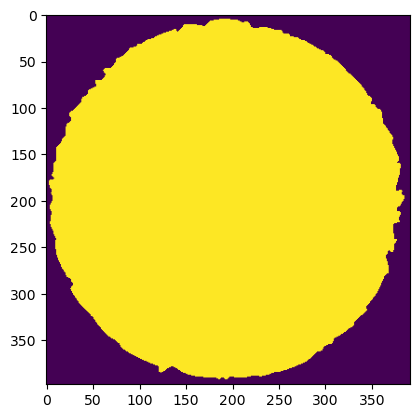

[2/9] /n/archive/labs/hsi-data/everyday_objects/kitchen/kaurahiutale1min/capture/
184


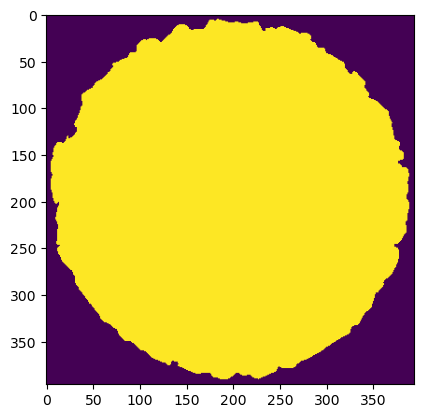

[3/9] /n/archive/labs/hsi-data/everyday_objects/kitchen/kuivahiiva/capture/
196


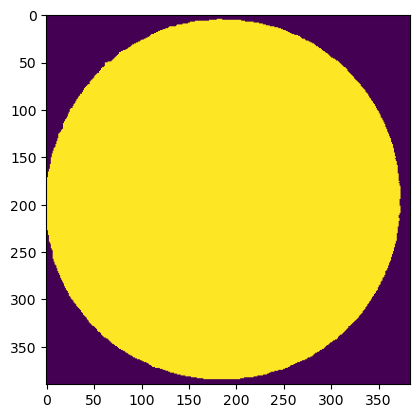

[4/9] /n/archive/labs/hsi-data/everyday_objects/kitchen/kvinoa/capture/
184


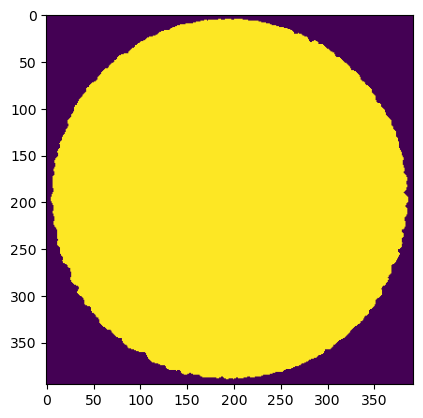

[5/9] /n/archive/labs/hsi-data/everyday_objects/kitchen/ohrahiutale_kasittelematon/capture/
184


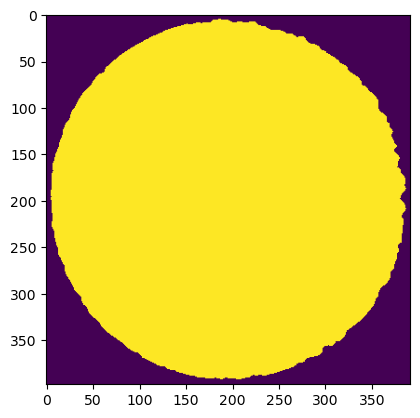

[6/9] /n/archive/labs/hsi-data/everyday_objects/kitchen/psyllium/capture/
189


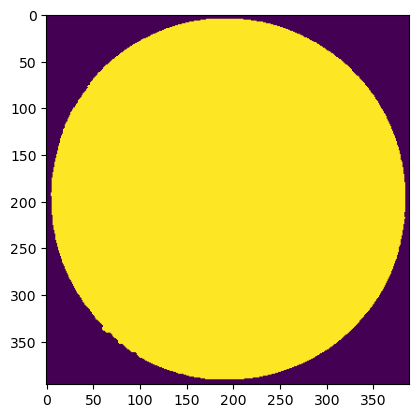

[7/9] /n/archive/labs/hsi-data/everyday_objects/kitchen/puuroriisi/capture/
158


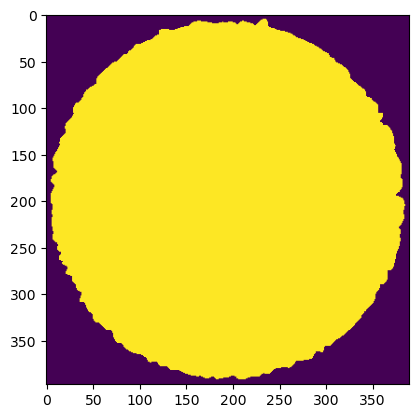

[8/9] /n/archive/labs/hsi-data/everyday_objects/kitchen/rikottu_ohrasuurimo/capture/
184


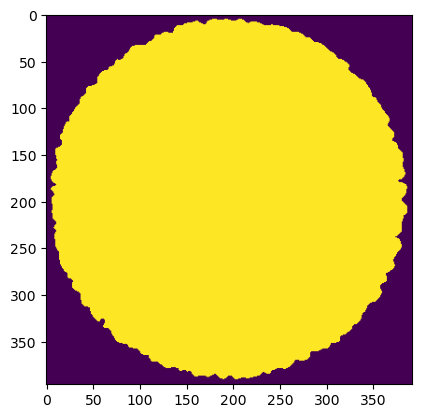

[9/9] /n/archive/labs/hsi-data/everyday_objects/kitchen/seesaminsiemen/capture/
191


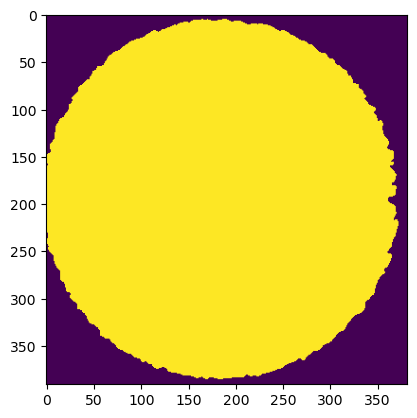


Processed 9/9 samples successfully.
There are 204 spectral bands in the cubes.
<class 'list'>


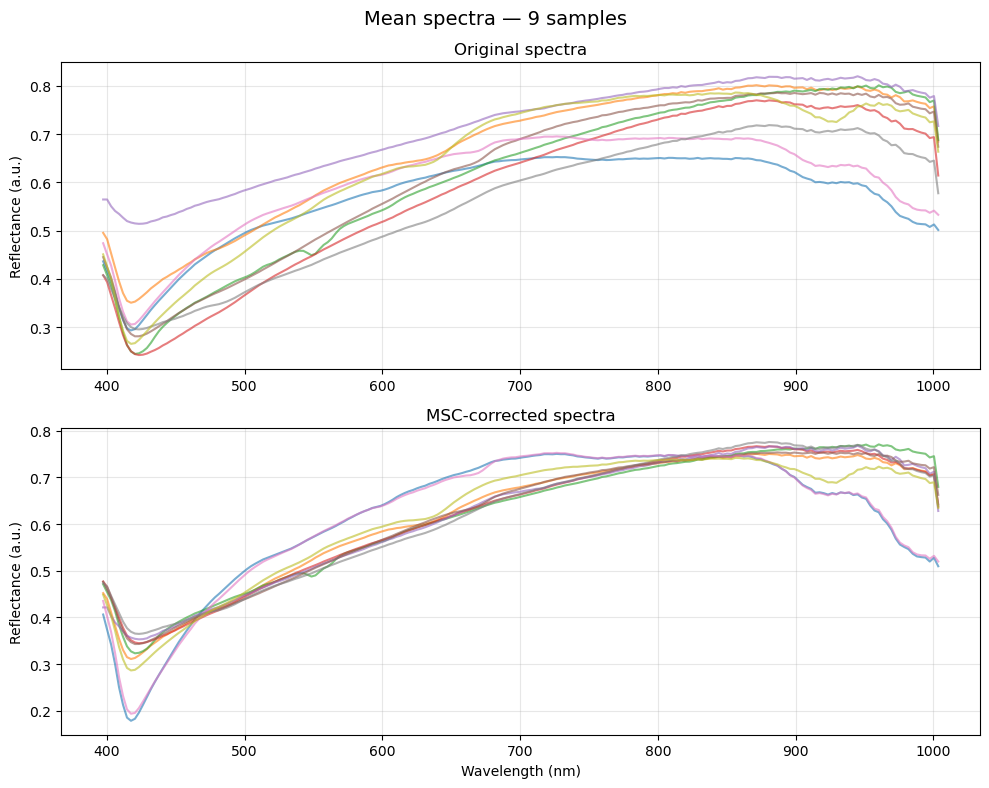

In [ ]:
print(f"Found {len(folders)} sample(s)\n")

spectra, names = [], []
wavelengths = None

for i, folder in enumerate(folders, 1):
    print(f"[{i}/{len(folders)}] ", end="")
    capture = os.path.join(PATH, folder, "capture/")
    print(capture)

    if not os.path.isdir(capture):
        print(f"  Skipping {folder}: no 'capture' subfolder.")
        continue

    spec, wl = process_sample(PATH, folder, nums[i-1])
    if spec is not None:
        spectra.append(spec)
        names.append(folder)
        if wavelengths is None:
            wavelengths = wl

spectra_msc, ref_spectrum = multiplicative_scatter_correction(spectra)


print(f"\nProcessed {len(spectra)}/{len(folders)} samples successfully.")

print(f"There are {len(wavelengths)} spectral bands in the cubes.")

plot_spectra(wavelengths, spectra, spectra_msc, title=f"Mean spectra — {len(names)} samples")

In [16]:
os.listdir('/n/archive/labs/hsi-data/everyday_objects/kitchen/sekoite2/capture/')

['WHITEREF_056.hdr',
 'WHITEDARKREF_056.hdr',
 'DARKREF_056.hdr',
 '056.raw',
 'WHITEREF_056.raw',
 'WHITEDARKREF_056.raw',
 '056.hdr',
 'DARKREF_056.raw']

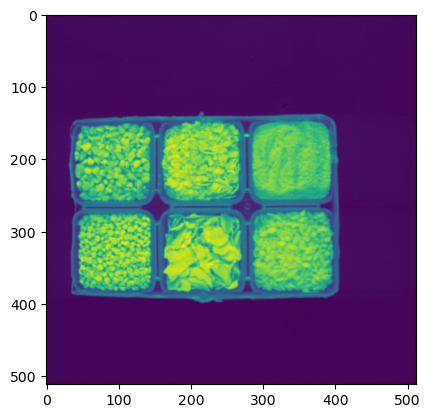

In [18]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/sekoite2/capture/056.hdr')

cube_raw = np.array(data_raw.asarray())

'''
i = 1

for p in range(0, i):
    plt.subplot(1, i+1, p+1)
    plt.imshow(cube_raw[:,:,int(p*(204/i))])
    plt.axis('off')
'''
plt.imshow(cube_raw[:,:,150])
plt.show()

# Spectral analysis

Muuttujat:
- PATH : string
    - `everyday_objects`-datan polku
- spectra : list
    - Käytettyjen kuvien spektrit
- names : list
    - Käytettyjen kansioiden nimet
- wavelengths : list
    - Aallonpituudet
- spectra_msc : numpy.ndarray
    - MSC-käsitellyt spektrit
- ref_spectrum : numpy.ndarray

In [21]:
reflectance, wavelengths = load_and_compute_reflectance(PATH, folders[0], nums[0])
mask = create_sample_mask(reflectance)
segmented, roi_mask = segment_sample(reflectance, mask)
type(segmented)

/tmp/ipykernel_2641610/3845093587.py:69: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_2641610/3845093587.py:73: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


numpy.ndarray

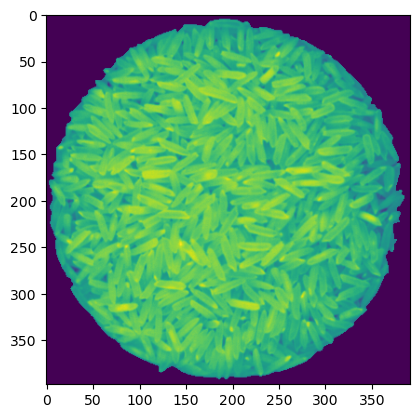

In [10]:
plt.imshow(segmented[:,:,150])
plt.show()

In [58]:
names = []
pixels = []

for n in range(len(folders)):
    cube, waves = load_and_compute_reflectance(PATH, folders[n], nums[n])
    mask = create_sample_mask(cube)
    segmented, roi_mask = segment_sample(cube, mask)
    i, j = np.nonzero(roi_mask)
    ix = np.random.choice(len(i), 20, replace=False)
    pixels.append(segmented[i[ix], j[ix],:])
    names.extend([nums[n] for i in range(20)])

# pixels = 9 * 20 pikseliä, kukin pikseli sisältää 204 kerrosta

p = []
for i in range(len(pixels)):
    for j in range(len(pixels[0])):
        p.append(pixels[i][j])

p = np.array(p)
print(len(names))

/tmp/ipykernel_2755379/3845093587.py:69: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_2755379/3845093587.py:73: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


180


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    p, names, test_size=0.25, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_pred
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}")

accuracy: 0.78
